# Simulation & Risk HW 1

In [19]:
# Load packages
import pandas as pd
import numpy as np
##!pip install openpyxl
import openpyxl
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
import statsmodels.api as sm
from scipy.stats import shapiro

In [20]:
# Load oil projection dataset
oil_projection = pd.read_excel("C:\\Users\\irvin\\Downloads\\Analysis_Data.xlsx", sheet_name='Price Projections', header=2)
oil_projection.head()

,Year,High Oil Price,Low Oil Price,AEO2023 Reference
0,2026,166.263016,45.745247,85.255096
1,2027,167.971329,46.518333,85.532898
2,2028,166.407440,47.305279,86.264732
3,2029,166.329147,47.445293,86.738144
4,2030,167.323944,47.981407,87.188271


In [21]:
# Load drilling cost dataset
drilling_cost = pd.read_excel("C:\\Users\\irvin\\Downloads\\Analysis_Data.xlsx", sheet_name='Drilling Cost', header=2)
drilling_cost.head()

,Date,U.S. Nominal Cost per Crude Oil Well Drilled (Thousand Dollars per Well),U.S. Nominal Cost per Natural Gas Well Drilled (Thousand Dollars per Well),U.S. Nominal Cost per Dry Well Drilled (Thousand Dollars per Well),Arithmetic Return - Crude Oil,Arithmetic Return - Natural Gas,Arithmetic Return - Dry Well
0,1960-06-30,52.2,102.7,44.0,.,.,.
1,1961-06-30,51.3,94.7,45.2,-0.017241,-0.077897,0.027273
2,1962-06-30,54.2,97.1,50.8,0.05653,0.025343,0.123894
3,1963-06-30,51.8,92.4,48.2,-0.04428,-0.048404,-0.051181
4,1964-06-30,50.6,104.8,48.5,-0.023166,0.134199,0.006224


In [22]:
# Only include infomration from 1990-2006
drilling_cost["Date"] = pd.to_datetime(drilling_cost["Date"])
drilling_cost = drilling_cost[drilling_cost['Date'].dt.year != 2007]
drilling_cost = drilling_cost[drilling_cost['Date'].dt.year > 1990]

In [23]:
# Get average cost in the most recent year across all three oil types. Starting point.
P0 = drilling_cost.iloc[15, [1, 2, 3]].mean()

In [24]:
# Convert data from wide to long format (48 observations)
drilling_cost_long = pd.melt(drilling_cost, id_vars=["Date"], 
                  var_name="Well Type", 
                  value_vars= ['Arithmetic Return - Natural Gas', 'Arithmetic Return - Dry Well', 'Arithmetic Return - Crude Oil'],
                  value_name="Cost_Change")

drilling_cost_long

,Date,Well Type,Cost_Change
0,1991-06-30,Arithmetic Return - Natural Gas,0.074899
1,1992-06-30,Arithmetic Return - Natural Gas,-0.158902
2,1993-06-30,Arithmetic Return - Natural Gas,0.223187
3,1994-06-30,Arithmetic Return - Natural Gas,0.026669
4,1995-06-30,Arithmetic Return - Natural Gas,0.176789
5,1996-06-30,Arithmetic Return - Natural Gas,-0.021756
6,1997-06-30,Arithmetic Return - Natural Gas,0.182792
7,1998-06-30,Arithmetic Return - Natural Gas,0.119407
8,1999-06-30,Arithmetic Return - Natural Gas,-0.021089
9,2000-06-30,Arithmetic Return - Natural Gas,-0.051979


In [25]:
# Make results repeatable (same random numbers each run)
SEED = 112358
rng = np.random.default_rng(SEED)

def summarize_sim(final_values: np.ndarray, initial_value: float = 1000.0) -> pd.DataFrame:
    """One-row summary: loss probability + 55% and 95% return levels."""
    final_values = np.asarray(final_values, dtype=float)
    returns = final_values / initial_value - 1.0

    loss_prob = float(np.mean(final_values < initial_value))
    q55 = float(np.quantile(returns, 0.55))
    q95 = float(np.quantile(returns, 0.95))

    return pd.DataFrame({
        "Initial Value": [initial_value],
        "Mean Final Value": [float(final_values.mean())],
        "Median Final Value": [float(np.median(final_values))],
        "Prob(Lose Money)": [loss_prob],
        "55% Return Level": [q55],
        "95% Return Level": [q95],
    })

In [26]:
# Calculate 6 year return (Normal Distribution)
n_sims = 10_000
n_years = 6
mu = drilling_cost_long['Cost_Change'].to_numpy().mean()
sigma = drilling_cost_long['Cost_Change'].to_numpy().std()

r = rng.normal(mu, sigma, size=(n_sims, n_years))
P6 = P0 * np.prod(1 + r, axis=1)

In [27]:
summarize_sim(P6, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4774.031495,4474.999373,0.0518,1.067351,2.627607


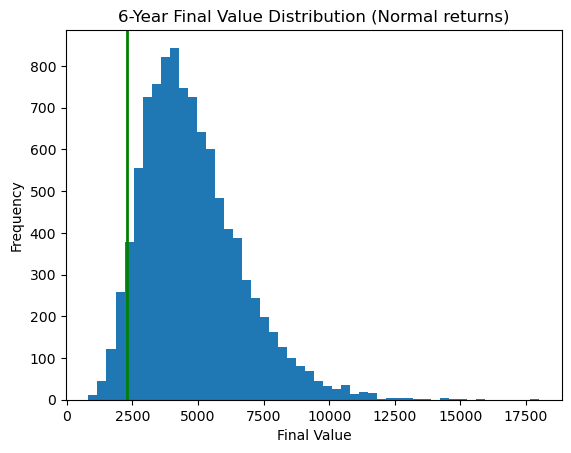

In [28]:
plt.figure()
plt.hist(P6, bins=50)
plt.axvline(P0, linewidth=2, color='green')
plt.title("6-Year Final Value Distribution (Normal returns)")
plt.xlabel("Final Value")
plt.ylabel("Frequency")
plt.show()

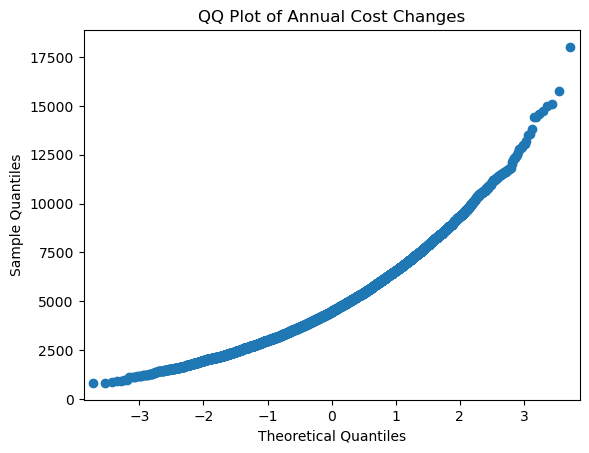

In [29]:
# QQ PLot
sm.qqplot(P6) 
plt.title("QQ Plot of Annual Cost Changes")
plt.show()

In [30]:
# Shapiro-Wilkes Test

stat, p = shapiro(P6)

print("Test Statistic:", stat)
print("p-value:", p)

Test Statistic: 0.9507229637199288
p-value: 2.0358799936870134e-49


c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [31]:
# Calculate 6 year return (KDE)
bandwidth = 0.07
n_sims = 10_000
n_years = 6

kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth)
kde.fit(drilling_cost_long['Cost_Change'].to_numpy().reshape(-1, 1))

sim_returns = kde.sample(n_sims * n_years, random_state=SEED)
sim_returns = sim_returns.reshape(n_sims, n_years)

P6_kde = P0 * np.prod(1 + sim_returns, axis=1)

display(summarize_sim(P6_kde, initial_value=P0))

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4801.93653,4448.322927,0.066,1.05869,2.76745


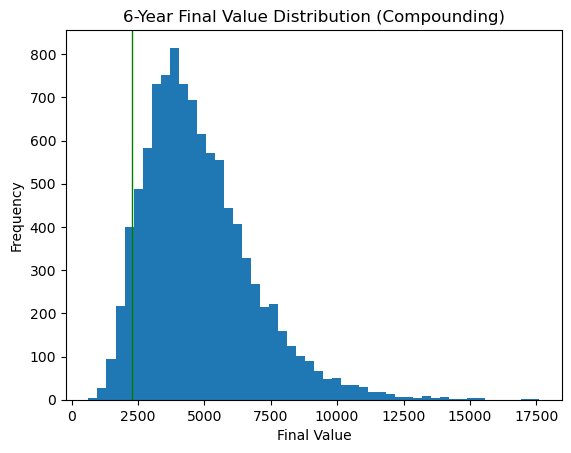

In [32]:
plt.figure()
plt.hist(P6_kde, bins=50)
plt.axvline(P0, linewidth=1, color='green')
plt.title("6-Year Final Value Distribution (Compounding)")
plt.xlabel("Final Value")
plt.ylabel("Frequency")
plt.show()

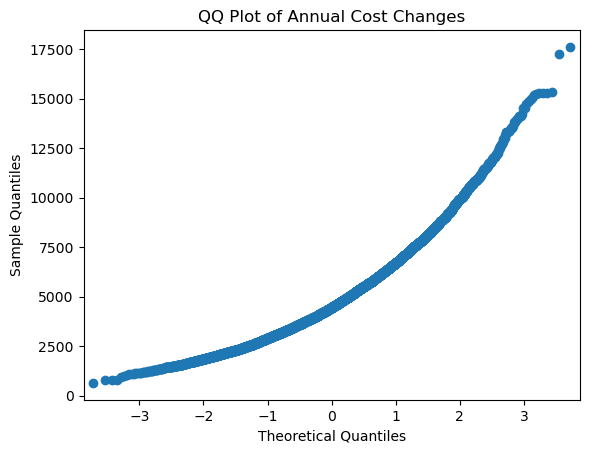

In [33]:
# QQ PLot
sm.qqplot(P6_kde) 
plt.title("QQ Plot of Annual Cost Changes")
plt.show()

In [34]:
# Shapiro-Wilkes Test

stat, p = shapiro(P6)

print("Test Statistic:", stat)
print("p-value:", p)

Test Statistic: 0.9507229637199288
p-value: 2.0358799936870134e-49


c:\Users\irvin\anaconda3\envs\irvin_intuition\Lib\site-packages\scipy\stats\_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


In [35]:
# Simulate Additional Years
##2012 - 2015
sim_12_15 = rng.uniform(-0.22, -0.07, size=(n_sims, 3))

##2015 - 2024
sim_15_24 = rng.uniform(0.02, 0.06, size=(n_sims, 9))

##2025 (distribution same as 2015-2024)
sim_25 = rng.uniform(0.02, 0.06, size=(n_sims, 1))

##Concatenate these into an array
future_changes = np.concatenate([sim_12_15, sim_15_24, sim_25], axis=1)

In [36]:
P2025_normal = P6 * np.prod(1 + future_changes, axis=1)

In [37]:
P2025_kde = P6_kde * np.prod(1 + future_changes, axis=1)

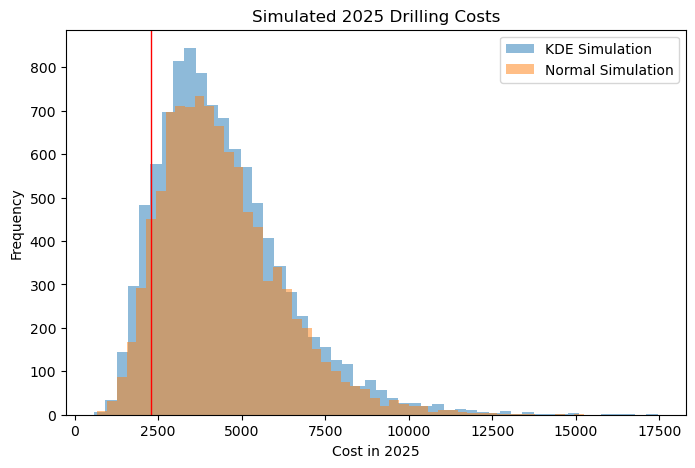

In [38]:
plt.figure(figsize=(8,5))

plt.hist(P2025_kde, bins=50, alpha=0.5, label="KDE Simulation")
plt.hist(P2025_normal, bins=50, alpha=0.5, label="Normal Simulation")
plt.axvline(P0, linewidth=1, color='red')

plt.title("Simulated 2025 Drilling Costs")
plt.xlabel("Cost in 2025")
plt.ylabel("Frequency")
plt.legend()

plt.show()

In [39]:
summarize_sim(P2025_normal, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4417.456653,4133.782913,0.0785,0.901979,2.390479


In [40]:
summarize_sim(P2025_kde, initial_value=P0)

,Initial Value,Mean Final Value,Median Final Value,Prob(Lose Money),55% Return Level,95% Return Level
0,2279.8,4443.711768,4091.745487,0.0982,0.905074,2.541294
